# Estimating Eigenvalues in Empirical Data

## Background

In this notebook we will explore how missing values affect the estimation of a the covariance matrix and the eigenvalues of the covariance matrix. We will first review some linear algebra concepts before we explore the above. If you know linear algebra or just don't care about math you can skip the background section and jump straight to the code. Missing values lead to noisy estimates of the covariance and can in some cases also lead to negative eigenvalues for the covariance matrix. 

### Positive Semi Definite Matrices
Recall that a $(n\times n)$ matrix $\Sigma$ is positive semidefinite if $x^T\Sigma x \geq 0, \forall x\in \mathbb{R}^n$. Equivalently, a $(n\times n)$ matrix $\Sigma$ is positive semidefinite if $\lambda_i \geq 0, \forall i\in \{1, \dots, n\}$, that is all eigenvalues are non-negative. To prove this we consider the characteristic equation:

$$
(\Sigma -\lambda I)x = 0\\
x^T(\Sigma -\lambda I)x = 0\\
x^T\Sigma x -x^T\lambda Ix = 0\\
x^T\Sigma x = \lambda x^Tx
$$
Now if $x^T\Sigma x \geq 0 \implies \lambda \geq 0$ and if $\lambda \geq 0 \implies x^T\Sigma x \geq 0$, so we have that the two definitions are equivalent.

### Data Simulation
To produce a positive semidefinite matrix $\Sigma$ we let $\Sigma = LL^T$ which is guaranteed to be $LL^T$ is guaranteed to be positive semidefinite. The proof of this is straightforward. Let $x \in \mathbb{R}^n$. We have that $x^Tx=\sum_{i=1}^n x_i^2\geq0$. We need to show that $x^TLL^Tx \geq 0$:
$$
x^TLL^Tx = (L^Tx)^T(L^Tx) = y^Ty \geq 0
$$

For our simulation we will use a multivariate normal distribution $X \sim \mathcal{N}(\mu, \Sigma)$ where $\mu\in\mathbb{R}^n$ and $\Sigma \in \mathbb{R}^{n\times n}$. To produce such an $X$ we set $X=\mu + LZ$ where $L$ is a lower triangular matrix and $Z\sim \mathcal{N}(0, I_n)$ where $I_n$ is the $n$-dimensional identity matrix. Using standard rules for expectation and variance we get:
$$
\mathbb{E}[X] = \mathbb{E}[\mu + LZ] = \mu\\
\text{Var}[X] = \text{Var}[\mu + LZ] = LI_nL^T = LL^T = \Sigma
$$
Since a linear combination of normally distributed variables are normally distributed we get $X \sim \mathcal{N}(\mu, \Sigma)$ as desired. In this experiment we use a lower triangular $L$ (see Cholesky decomposition for more on this).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf

seed = 42
np.set_printoptions(precision=2, suppress=True)
np.random.seed(seed)

In [14]:
m = 10_000
n = 3
Z = np.random.randn(m, n)

In [15]:
Z = np.random.randn(m, n)

L = np.array([
    [1, 0, 0], 
    [2, 1, 0], 
    [-3, 1, 1]
])
sigma = L @ L.T
np.fill_diagonal(L, 1)
mu = np.random.randn(n, 1)

X = mu + L @ Z.T
print("Theoretical covariance matrix:")
print(sigma)
print("Sample covariance matrix:")
print(np.cov(X))


Theoretical covariance matrix:
[[ 1  2 -3]
 [ 2  5 -5]
 [-3 -5 11]]
Sample covariance matrix:
[[ 1.01  2.04 -3.02]
 [ 2.04  5.08 -5.06]
 [-3.02 -5.06 10.99]]


From the above we can see that the theoretical and sample covariance matrices coincide.

## Introducing Missing Values and Calculating Eigenvalues

In a perfect environment we can easily estimate the covariance, but in reality we might have missing data. In the following section we introduce missing value into our data to simulate a real world environment. We randomly choose an $\eta \in [0, 1)$ fraction of the $X$ matrix to be missing. That is if $\eta=0$ we have the original matrix and if $\eta=1$ the $X$ matrix will be all missing values. $\eta = 1$ does not really makes sense so we have a right-open interval for the noise fraction. After introducing missing values, we calculate the covariance matrix of the resulting matrix and the eigenvalues of the covariance matrix. We bootstrap and do this $B$ times to get uncertainty estimates of the eigenvalues. We finally plot boxplots for all eigenvalues at each noise level.

In [29]:
def bootstrap_eigenvalues(X: np.ndarray, B: int = 100, etas: np.ndarray = np.linspace(0.0, 0.8, 9), shrinkage: bool = False):
    """
    Bootstrap the eigenvalues of the covariance matrix of X for different noise levels.
    Args:
        X: The data matrix of shape (m, n).
        B: The number of bootstrap samples.
        etas: The noise levels to use.
    Returns:
        eigenvalues_samples: The eigenvalues of the covariance matrix of X for different noise levels of shape (n, B, len(etas)).
    """
    eigenvalues_samples, shrinkage_samples = [], []
    for noise_level in etas:
        eigenvalues_noise_level, shrinkage_noise_level = [], []
        for _ in range(B):
            mask_na = np.random.choice([True, False], size=X.shape, p=[1-noise_level, noise_level])
            X_noisy = np.where(mask_na, X, np.nan)
            df = pd.DataFrame(X_noisy.T)
            cov_noisy = df.cov().to_numpy()
            try:
                eigenvalues_noisy = np.linalg.eigvals(cov_noisy)
            except np.linalg.LinAlgError as e:
                print(f"Error calculating eigenvalues for noise level {noise_level}: {e}")
                eigenvalues_noisy = np.zeros(X.shape[1])
            if shrinkage:
                try:
                    cov_noisy_ledoit_wolf = LedoitWolf().fit(df.dropna()).covariance_
                    eigenvalues_noisy_ledoit_wolf = np.linalg.eigvals(cov_noisy_ledoit_wolf)
                except np.linalg.LinAlgError as e:
                    print(f"Error calculating eigenvalues for noise level {noise_level}: {e}")
                    eigenvalues_noisy_ledoit_wolf = np.zeros(X.shape[1])

                shrinkage_noise_level.append(eigenvalues_noisy_ledoit_wolf)
            eigenvalues_noise_level.append(eigenvalues_noisy)

        eigenvalues_samples.append(np.array(eigenvalues_noise_level))
        if shrinkage:
            shrinkage_samples.append(np.array(shrinkage_noise_level))

    eigenvalues_samples = np.array(eigenvalues_samples)
    eigenvalues_samples = np.swapaxes(eigenvalues_samples, 0, 2)
    if shrinkage:
        shrinkage_samples = np.array(shrinkage_samples)
        shrinkage_samples = np.swapaxes(shrinkage_samples, 0, 2)
        return eigenvalues_samples, shrinkage_samples
    return eigenvalues_samples

### Examples

In the below examples we see that the estimation of the covariance matrix and therefore the eigenvalues become more noisy the more missing values we introduce. There does not seem to be much bias, but the variance increases. In the second example we even get negative eigenvalues. Recall from the background that this should not be possible as covariance matrices are supposed to be positive semidefinite. This happens when the true eigenvalue are close to $0$. This can be solved with setting negative eigenvalues to $0$. However, this does not solve the issue of noisy estimates of the covariance matrix which will be the topic of the next section.

Correlation matrix:
[[ 1.    0.24 -0.93]
 [ 0.24  1.   -0.38]
 [-0.93 -0.38  1.  ]]


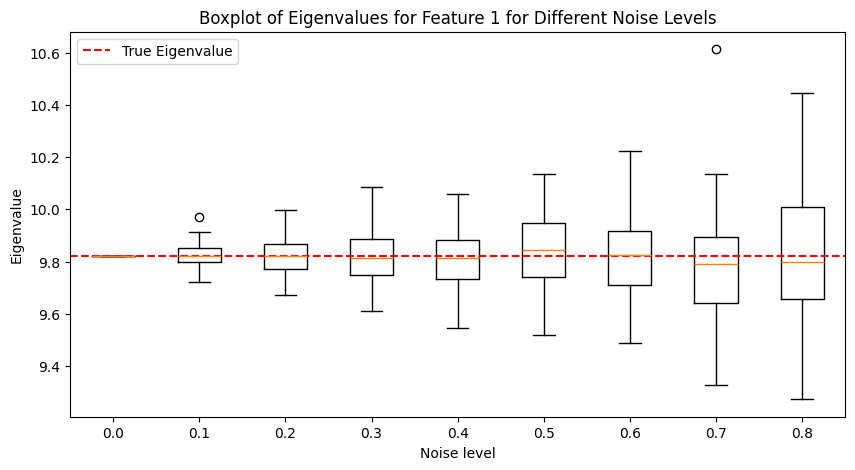

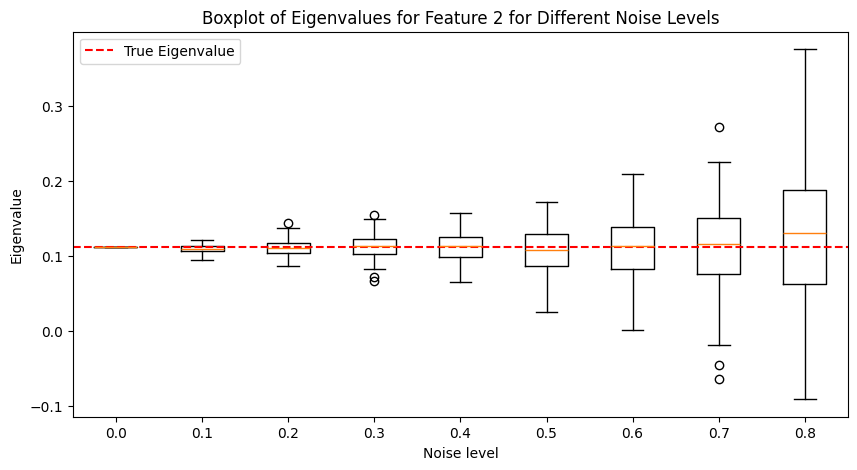

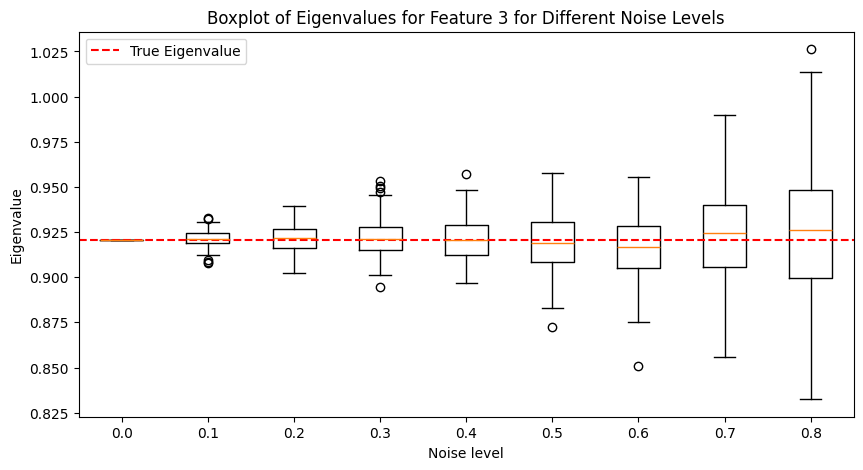

In [17]:
Z = np.random.randn(m, n)

L = np.tril(np.random.randn(n, n))
np.fill_diagonal(L, 1)
mu = np.random.randn(n, 1)

X = mu + L @ Z.T

eigenvalues_samples = bootstrap_eigenvalues(X)
true_eigenvalues = np.linalg.eigvals(np.cov(X))

print("Correlation matrix:")
print(np.corrcoef(X))

tick_labels = np.linspace(0.0, 0.8, 9)
tick_labels = [f"{tick:.1f}" for tick in tick_labels]

for i in range(X.shape[0]):
    plt.figure(figsize=(10, 5))
    plt.boxplot(eigenvalues_samples[i], tick_labels=tick_labels)
    plt.axhline(y=true_eigenvalues[i], color='r', linestyle='--', label='True Eigenvalue')
    plt.title(f'Boxplot of Eigenvalues for Feature {i+1} for Different Noise Levels')
    plt.xlabel('Noise level')
    plt.ylabel('Eigenvalue')
    plt.legend()
    plt.show()


Correlation matrix:
[[1.   1.   0.72]
 [1.   1.   0.78]
 [0.72 0.78 1.  ]]


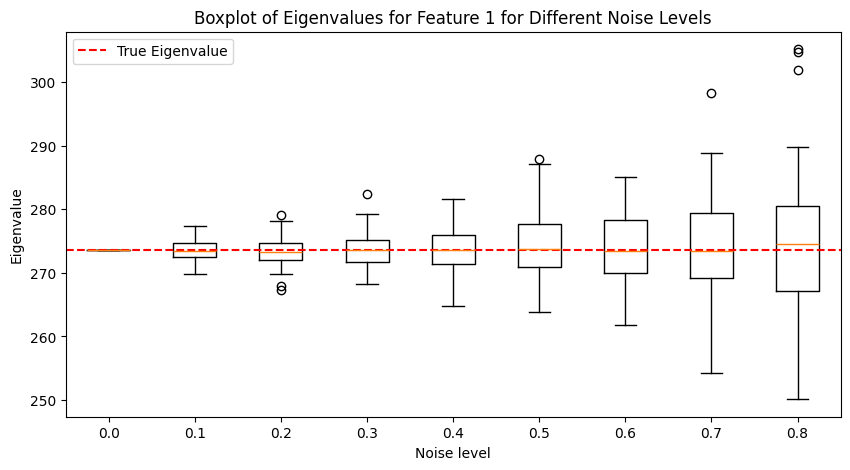

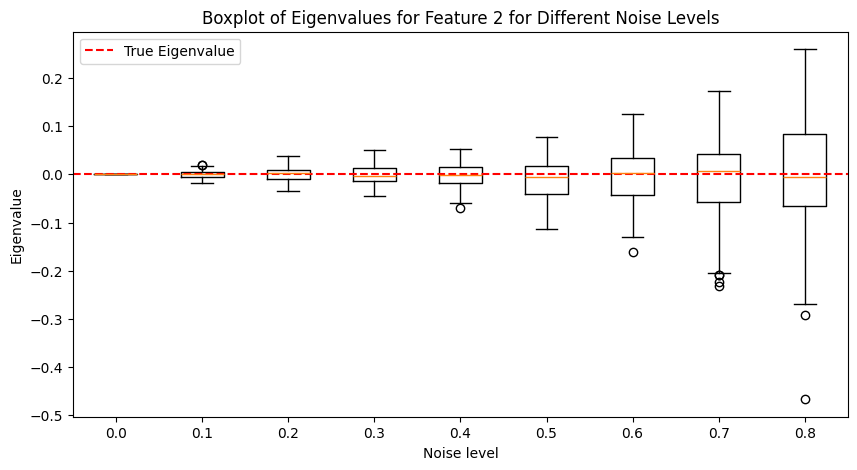

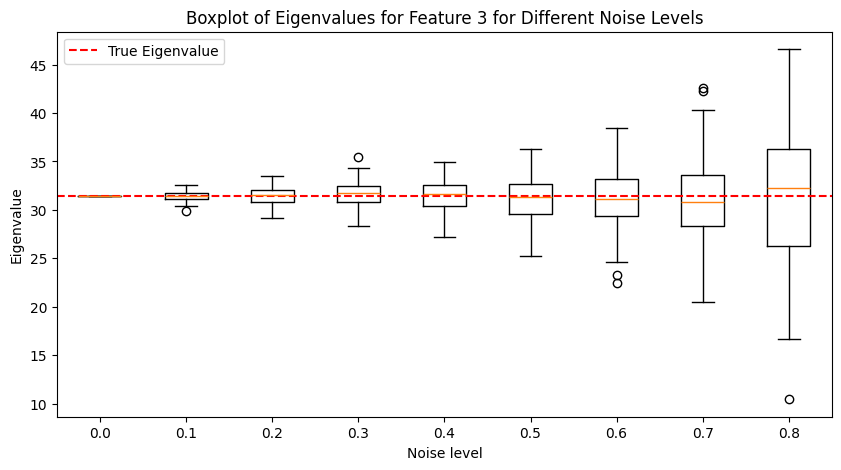

In [18]:
Z = np.random.randn(m, n)

L = 10*np.tril(np.random.uniform(0.9, 1.1, size=(n, n)))
np.fill_diagonal(L, 1)
mu = np.random.randn(n, 1)

X = mu + L @ Z.T

eigenvalues_samples = bootstrap_eigenvalues(X)
true_eigenvalues = np.linalg.eigvals(np.cov(X))

print("Correlation matrix:")
print(np.corrcoef(X))

tick_labels = np.linspace(0.0, 0.8, 9)
tick_labels = [f"{tick:.1f}" for tick in tick_labels]

for i in range(X.shape[0]):
    plt.figure(figsize=(10, 5))
    plt.boxplot(eigenvalues_samples[i], tick_labels=tick_labels)
    plt.axhline(y=true_eigenvalues[i], color='r', linestyle='--', label='True Eigenvalue')
    plt.title(f'Boxplot of Eigenvalues for Feature {i+1} for Different Noise Levels')
    plt.xlabel('Noise level')
    plt.ylabel('Eigenvalue')
    plt.legend()
    plt.show()


## Variance Reduction Techniques for Estimating Covariance Matrix

There are several ways one could handle this. One way to deal with this is Ledoit-Wolf shrinkage which shrinks the covariance matrix towards a targeted covariance matrix. The targeted covariance matrix is often all covariances. Your prior is therefore that all features have the same covariance. This can be good for high-dimensional as covariance matrices of high-dimensional data are often noisy. Sklearn even has an implementation of the Ledoit-Wolf shirnkage.

Correlation matrix:
[[1.   0.55 0.29]
 [0.55 1.   0.71]
 [0.29 0.71 1.  ]]


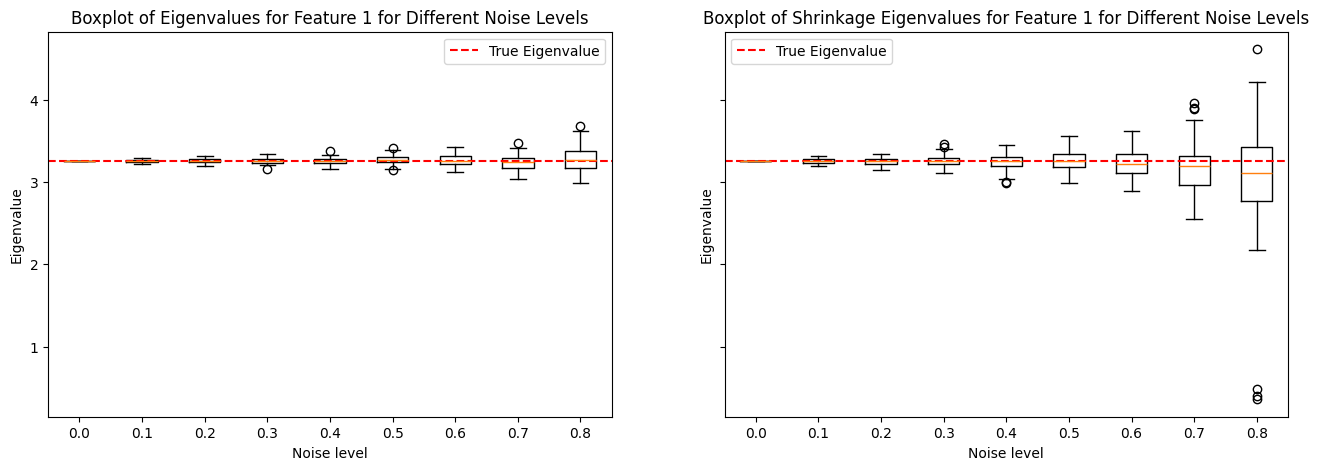

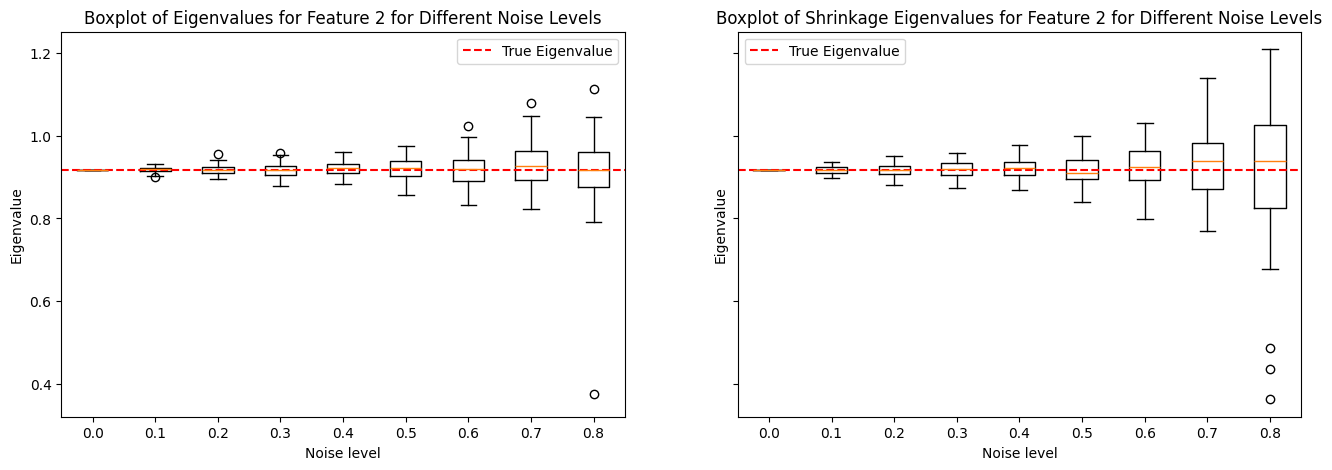

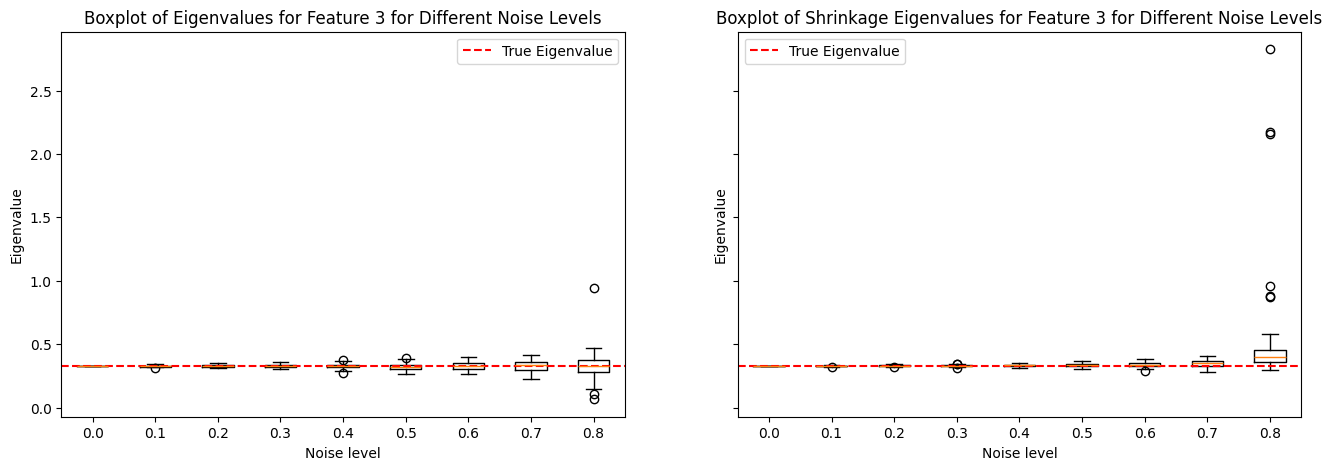

In [36]:
Z = np.random.randn(m, n)

L = np.tril(np.random.randn(n, n))
np.fill_diagonal(L, 1)
mu = np.random.randn(n, 1)

X = mu + L @ Z.T

eigenvalues_samples, shrinkage_samples = bootstrap_eigenvalues(X, shrinkage=True)
true_eigenvalues = np.linalg.eigvals(np.cov(X))

print("Correlation matrix:")
print(np.corrcoef(X))

tick_labels = np.linspace(0.0, 0.8, 9)
tick_labels = [f"{tick:.1f}" for tick in tick_labels]

for i in range(X.shape[0]):
    fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    axs[0].boxplot(eigenvalues_samples[i], tick_labels=tick_labels)
    axs[1].boxplot(shrinkage_samples[i], tick_labels=tick_labels)
    axs[0].axhline(y=true_eigenvalues[i], color='r', linestyle='--', label='True Eigenvalue')
    axs[1].axhline(y=true_eigenvalues[i], color='r', linestyle='--', label='True Eigenvalue')
    axs[0].set_title(f'Boxplot of Eigenvalues for Feature {i+1} for Different Noise Levels')
    axs[1].set_title(f'Boxplot of Shrinkage Eigenvalues for Feature {i+1} for Different Noise Levels')
    axs[0].set_xlabel('Noise level')
    axs[1].set_xlabel('Noise level')
    axs[0].set_ylabel('Eigenvalue')
    axs[1].set_ylabel('Eigenvalue')
    axs[0].legend()
    axs[1].legend()
    plt.show()